### Something here

In [3]:
# Write some codes, build a model

In [4]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Getting the cars data
df = pd.read_csv("../data/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [6]:
# Get info about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [7]:
# See numerical data
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
# See categorical(string) data, which may also include some numerical ones
df.describe(include='str')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,8128,8128,8128,8128,8128,7907,7907,7913,7906
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,129,4402,6766,7078,5289,225,1017,377,530


In [9]:
# Check nulls
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [10]:
# I should remove the null values now but I want to try the mapping first and see what happens.
# I will deal with null values after the mapping.

### Data Cleaning

In [11]:
# Looking the "owner" feature
df["owner"].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [12]:
# As per instruction, we will map owner types to numerical values.
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}
df["owner"] = df["owner"].map(owner_mapping)
df["owner"].value_counts()

owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

In [13]:
# Looking the "fuel" feature
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [14]:
# As per instruction, we will remove CNG and LPG rows
df = df[~df["fuel"].isin(["CNG", "LPG"])].copy()
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
Name: count, dtype: int64

In [15]:
# Looking the "milage" feature, extracts everything after the last space (the unit) and counts them
df["mileage"].str.extract(r'(\s\w+)$')[0].value_counts()


0
kmpl    7819
Name: count, dtype: int64

In [16]:
# Now we made sure they are all "kmpl", we remove the unit 
df["mileage"] = (
    df["mileage"]
    .str.split()
    .str[0]
    .astype(float)
)
df["mileage"].head(10)

0     23.40
1     21.14
2     17.70
3     23.00
4     16.10
5     20.14
7     16.10
8     23.59
9     20.00
10    19.01
Name: mileage, dtype: float64

In [17]:
# Looking the "engine" feature, extracts everything after the last space (the unit) and counts them
df["engine"].str.extract(r'(\s\w+)$')[0].value_counts()

0
CC    7819
Name: count, dtype: int64

In [18]:
# Now we made sure they are all "CC", we remove the unit 
df["engine"] = (
    df["engine"]
    .str.split()
    .str[0]
    .astype(float)
)
df["engine"].head(10)

0     1248.0
1     1498.0
2     1497.0
3     1396.0
4     1298.0
5     1197.0
7      796.0
8     1364.0
9     1399.0
10    1461.0
Name: engine, dtype: float64

In [19]:
# Looking the "max_power" feature, extracts everything after the last space (the unit) and counts them
df["max_power"].str.extract(r'(\s\w+)$')[0].value_counts()

0
bhp    7819
Name: count, dtype: int64

In [20]:
# Now we made sure they are all "bhp", we remove the unit 
df["max_power"] = (
    df["max_power"]
    .str.split()
    .str[0]
    .astype(float)
)
df["max_power"].head(10)

0      74.00
1     103.52
2      78.00
3      90.00
4      88.20
5      81.86
7      37.00
8      67.10
9      68.10
10    108.45
Name: max_power, dtype: float64

In [21]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
torque           214
seats            214
dtype: int64

In [22]:
# Columns with null values
null_cols = ["mileage", "engine", "max_power", "torque", "seats"]

# Filter rows where we found null values
null_rows_df = df[df[null_cols].isnull().any(axis=1)]

# View the rows
print(f"Total rows with at least one null: {len(null_rows_df)}")
null_rows_df[null_cols].head(10)

Total rows with at least one null: 214


,mileage,engine,max_power,torque,seats
13,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,NaN
87,NaN,NaN,NaN,NaN,NaN
119,NaN,NaN,NaN,NaN,NaN
138,NaN,NaN,NaN,NaN,NaN
200,NaN,NaN,NaN,NaN,NaN
206,NaN,NaN,NaN,NaN,NaN
228,NaN,NaN,NaN,NaN,NaN
252,NaN,NaN,NaN,NaN,NaN


In [23]:
# Okay as we saw that all those null values are happening in same rows, 
# I will just drop those rows.
df = df.dropna(subset=null_cols)
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


In [39]:
# As per instruction, we will only take the first word for "brand" feature
# We will rename "name" to "brand"
df.rename(columns={'name': 'brand'},inplace=True)
df["brand"] = df["brand"].str.split().str[0]
df.head(10)

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,1,20.14,1197.0,81.86,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,2,16.10,796.0,37.00,4.0
8,Toyota,2011,350000,90000,Diesel,Individual,Manual,1,23.59,1364.0,67.10,5.0
9,Ford,2013,200000,169000,Diesel,Individual,Manual,1,20.00,1399.0,68.10,5.0
10,Renault,2014,500000,68000,Diesel,Individual,Manual,2,19.01,1461.0,108.45,5.0


In [25]:
# As per instruction, drop "torque" feature
df = df.drop(columns=["torque"])
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,1,20.14,1197.0,81.86,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,2,16.10,796.0,37.00,4.0
8,Toyota,2011,350000,90000,Diesel,Individual,Manual,1,23.59,1364.0,67.10,5.0
9,Ford,2013,200000,169000,Diesel,Individual,Manual,1,20.00,1399.0,68.10,5.0
10,Renault,2014,500000,68000,Diesel,Individual,Manual,2,19.01,1461.0,108.45,5.0


In [26]:
# Finding out about "Test Drive Cars", we already did the mapping so it is 5
test_cars = df[df['owner'] == 5]
test_cars

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4383,Volkswagen,2019,1350000,5400,Diesel,Dealer,Manual,5,22.27,1498.0,108.60,5.0
4950,Audi,2019,6223000,7800,Petrol,Dealer,Automatic,5,15.26,1798.0,187.74,5.0
4951,Audi,2019,5923000,11500,Petrol,Dealer,Automatic,5,15.26,1798.0,187.74,5.0
4952,Audi,2019,6523000,23600,Petrol,Dealer,Automatic,5,15.26,1798.0,187.74,5.0
6220,Honda,2019,2000000,24857,Petrol,Dealer,Automatic,5,16.50,1799.0,139.46,5.0


In [27]:
# As per instructions, we will drop "Test Drive Car" which is 5
before = len(df)
df = df[df["owner"] != 5].copy()
print(f"Dropped: {len(df) - before} rows")

Dropped: -5 rows


### EDA

In [40]:
# As per instruction, we will log(selling price)
# Normally, it is safer to use log1p, but now we already check null values
# So we will just use np.log()
# df["selling_price"] = np.log(df["selling_price"])
# Before that, we should see the graphs first

In [41]:
# Overview
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.info())

print("\nSummary Statistics")
df.describe()


Dataset Shape
(7814, 12)

Data Types
<class 'pandas.DataFrame'>
Index: 7814 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          7814 non-null   object 
 1   year           7814 non-null   int64  
 2   selling_price  7814 non-null   int64  
 3   km_driven      7814 non-null   int64  
 4   fuel           7814 non-null   str    
 5   seller_type    7814 non-null   str    
 6   transmission   7814 non-null   str    
 7   owner          7814 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   float64
 10  max_power      7814 non-null   float64
 11  seats          7814 non-null   float64
dtypes: float64(4), int64(4), object(1), str(3)
memory usage: 793.6+ KB
None

Summary Statistics


,year,selling_price,km_driven,owner,mileage,engine,max_power,seats
count,7814.000000,7.814000e+03,7.814000e+03,7814.000000,7814.000000,7814.000000,7814.000000,7814.000000
mean,2013.987074,6.515864e+05,6.916070e+04,1.443819,19.391962,1462.914640,91.890230,5.421551
std,3.864426,8.097971e+05,5.687495e+04,0.704962,4.001972,504.759742,35.727695,0.963125
min,1994.000000,2.999900e+04,1.000000e+03,1.000000,0.000000,624.000000,34.200000,2.000000
25%,2012.000000,2.700000e+05,3.400000e+04,1.000000,16.780000,1197.000000,69.000000,5.000000
50%,2015.000000,4.550000e+05,6.000000e+04,1.000000,19.300000,1248.000000,82.400000,5.000000
75%,2017.000000,6.950000e+05,9.600000e+04,2.000000,22.320000,1582.000000,102.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,4.000000,42.000000,3604.000000,400.000000,14.000000


In [47]:
from sklearn.model_selection import train_test_split

# Split the dataset, for now I will not seperate X and y yet.
# This is for EDA
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"• Training data: {df_train.shape}")
print(f"• Testing data: {df_test.shape}")


• Training data: (6251, 12)
• Testing data: (1563, 12)


In [51]:
# Locate the complete row profile of the maximum priced car
most_expensive_car = df_train.loc[df_train['selling_price'].idxmax()]
most_expensive_car


brand                 Volvo
year                   2017
selling_price      10000000
km_driven             30000
fuel                 Petrol
seller_type      Individual
transmission      Automatic
owner                     1
mileage                42.0
engine               1969.0
max_power             400.0
seats                   4.0
Name: 170, dtype: object

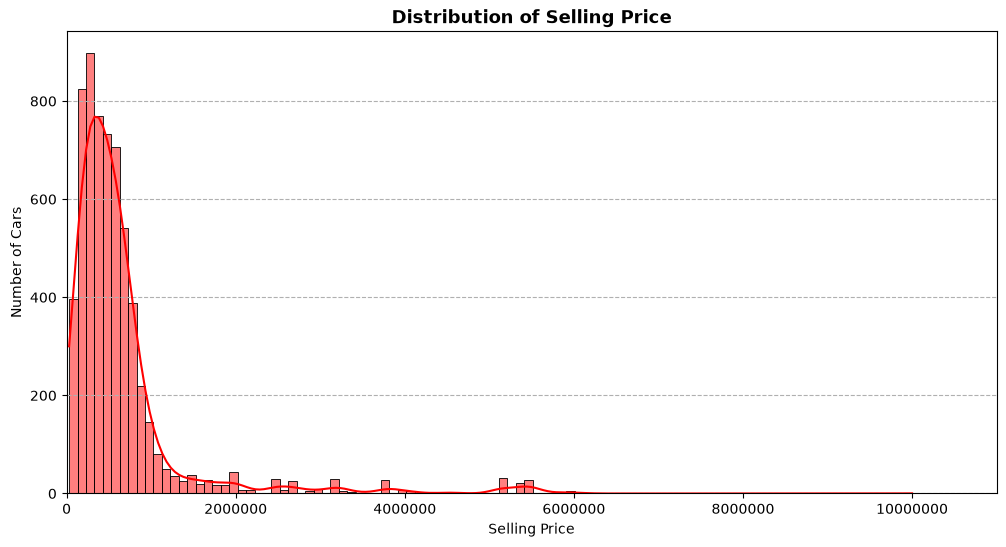

In [121]:
# Find max price
max_price = df_train["selling_price"].max()

# Add some padding
upper_limit = max_price * 1.10

# Create the plot for selling price
plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x="selling_price",color="red", kde=True, bins=100)

# Range
plt.xlim(0, upper_limit)

# Clean up scientific notation format
plt.ticklabel_format(style='plain', axis='x')

plt.title(f'Distribution of Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.show()

### Brand

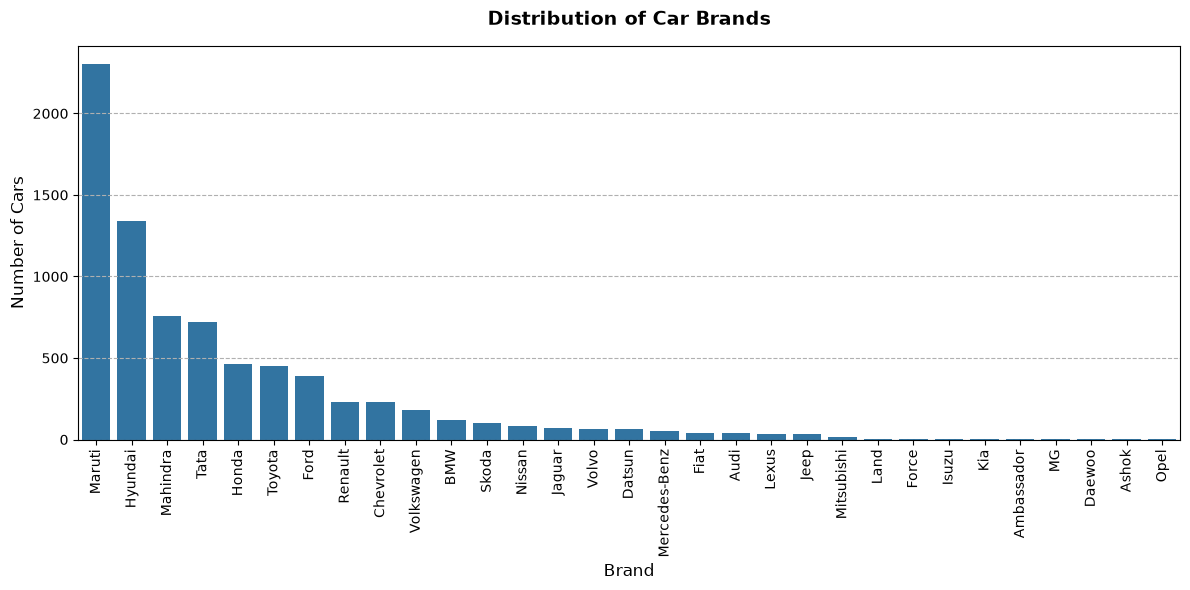

In [120]:
# Create the plot for "brand"
plt.figure(figsize=(12, 6))

# Get brand counts sorted from highest to lowest
brand_counts = df['brand'].value_counts()

sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.xticks(rotation=90)

# Add labels and formatting
plt.title('Distribution of Car Brands', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


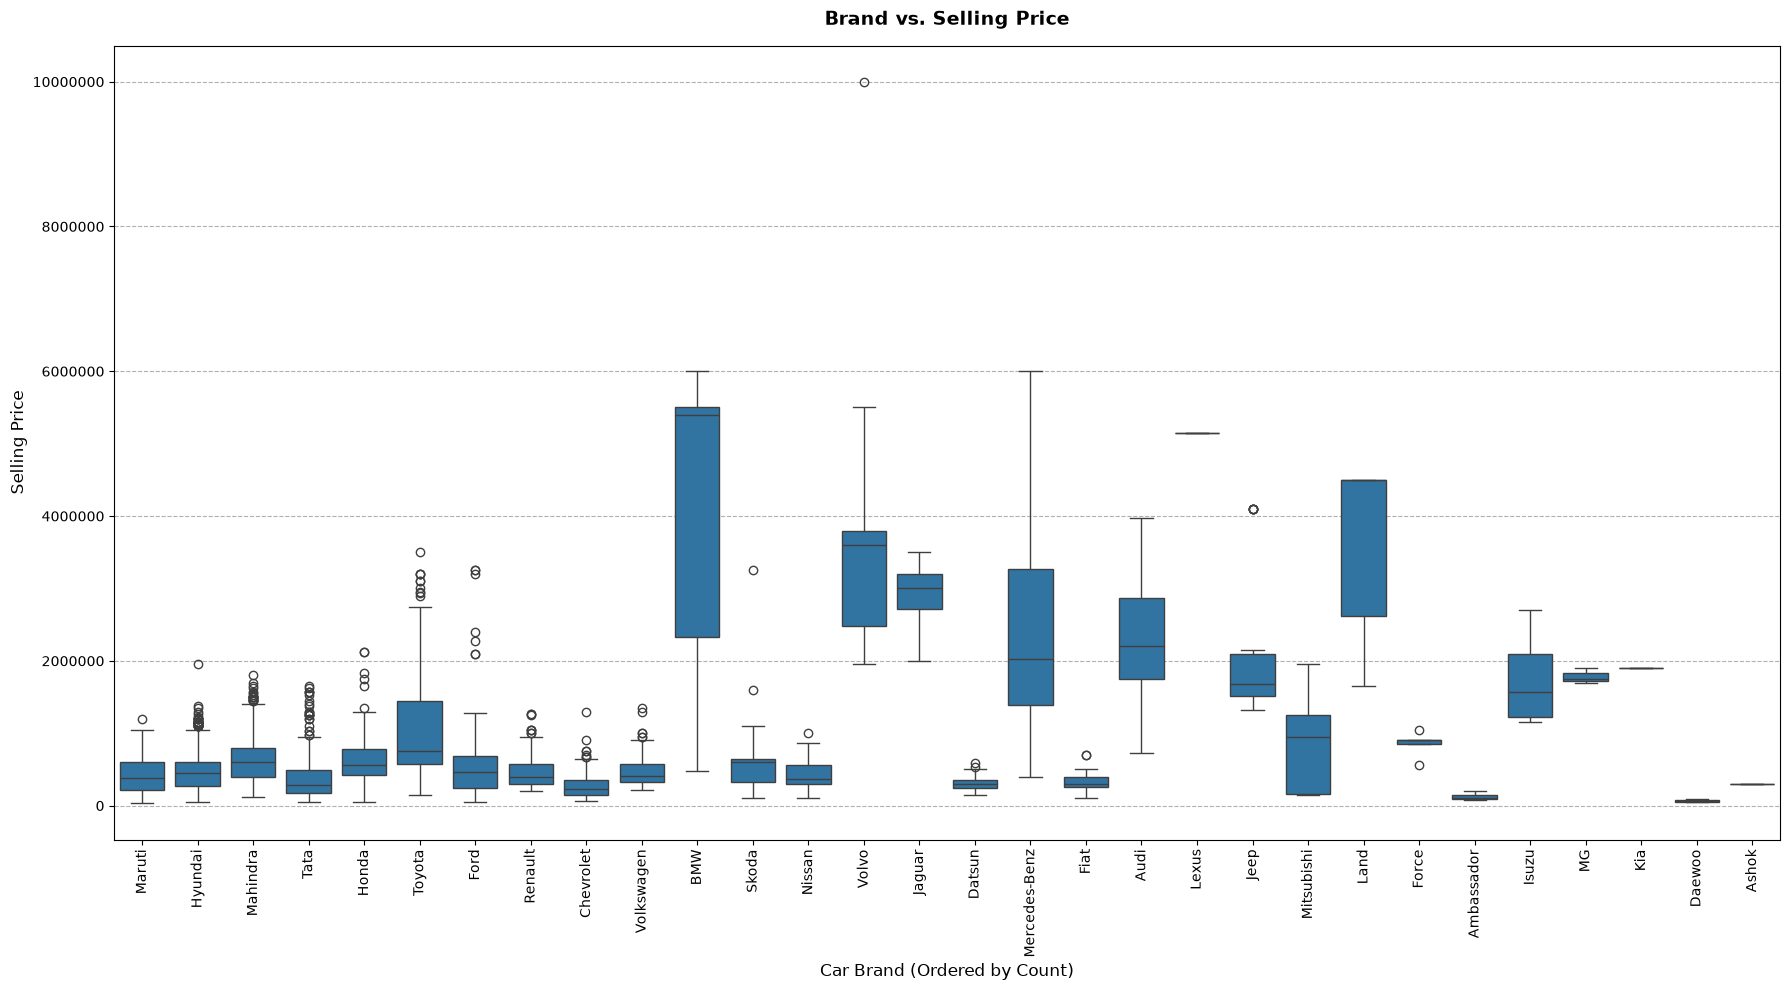

In [106]:

# Order brands by counts
brands_counts = df_train['brand'].value_counts().index.tolist()

# Get data
df_brands = df_train[df_train['brand'].isin(brands_counts)]

plt.figure(figsize=(18, 10))

# Boxplot helps see the median, 25th, and 75th percentiles clearly
sns.boxplot(
    data=df_brands, 
    x='brand', 
    y='selling_price', 
    order=brands_counts
)

# Clean up scientific notation on the pricing axis
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)

plt.title('Brand vs. Selling Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Car Brand (Ordered by Count)', fontsize=12, )
plt.ylabel('Selling Price', fontsize=12)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


### Year

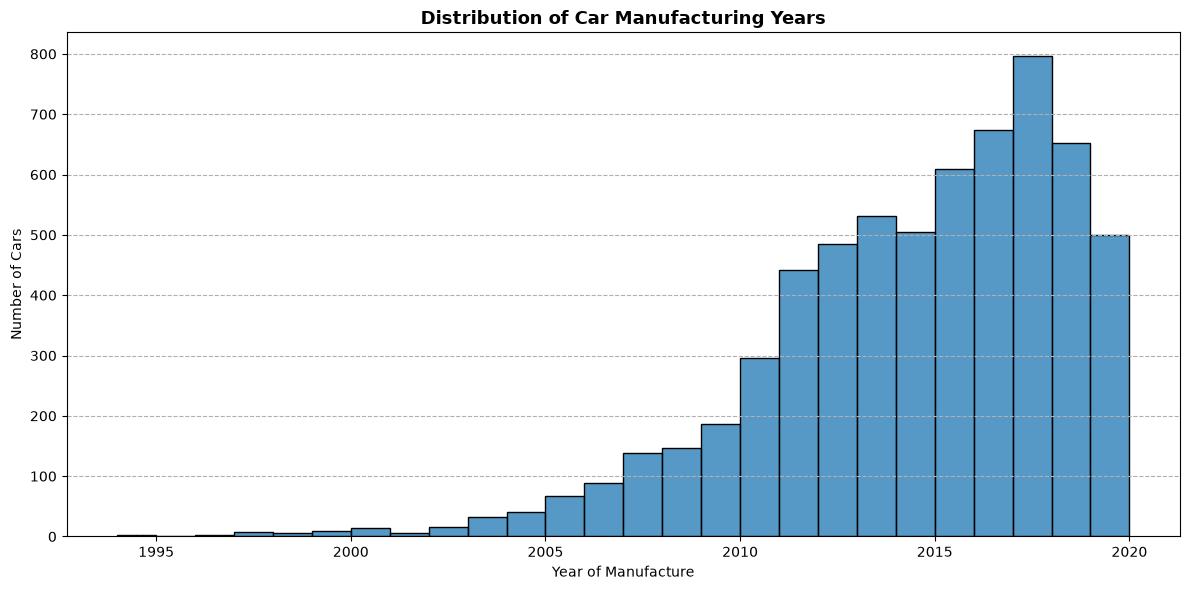

In [119]:
plt.figure(figsize=(12, 6))

# Plot counts of cars for each manufacturing year
sns.histplot(data=df_train, x='year', binwidth=1)

plt.title('Distribution of Car Manufacturing Years', fontsize=13, fontweight='bold')
plt.xlabel('Year of Manufacture')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

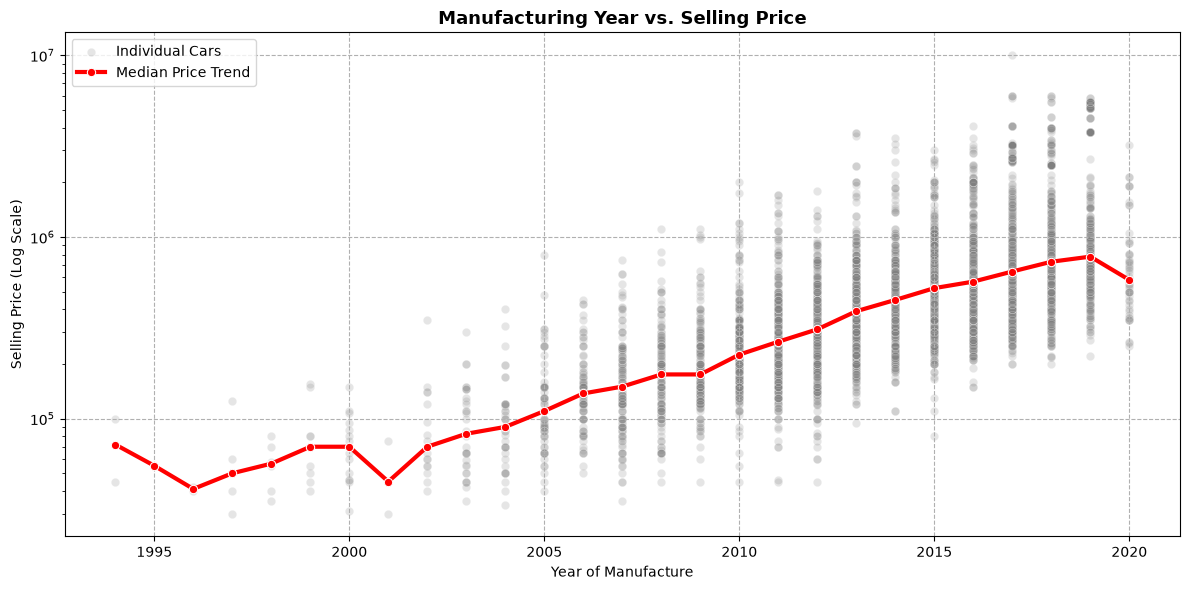

In [104]:
plt.figure(figsize=(12, 6))

# 1. Plot individual cars as light background dots to see data density
sns.scatterplot(data=df_train, x='year', y='selling_price', color='gray', alpha=0.2, label='Individual Cars')

# 2. Overlay a thick line tracking the MEDIAN price for each year to see the true trend
sns.lineplot(data=df_train, x='year', y='selling_price', estimator='median', errorbar=None, color='red', linewidth=3, marker='o', label='Median Price Trend')

# Formatting adjustments
plt.yscale('log') # Log scale keeps pricing curves visible across decades

plt.title('Manufacturing Year vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price (Log Scale)')
plt.legend()
plt.grid(axis='both', linestyle='--')

plt.tight_layout()
plt.show()


### KM_Driven

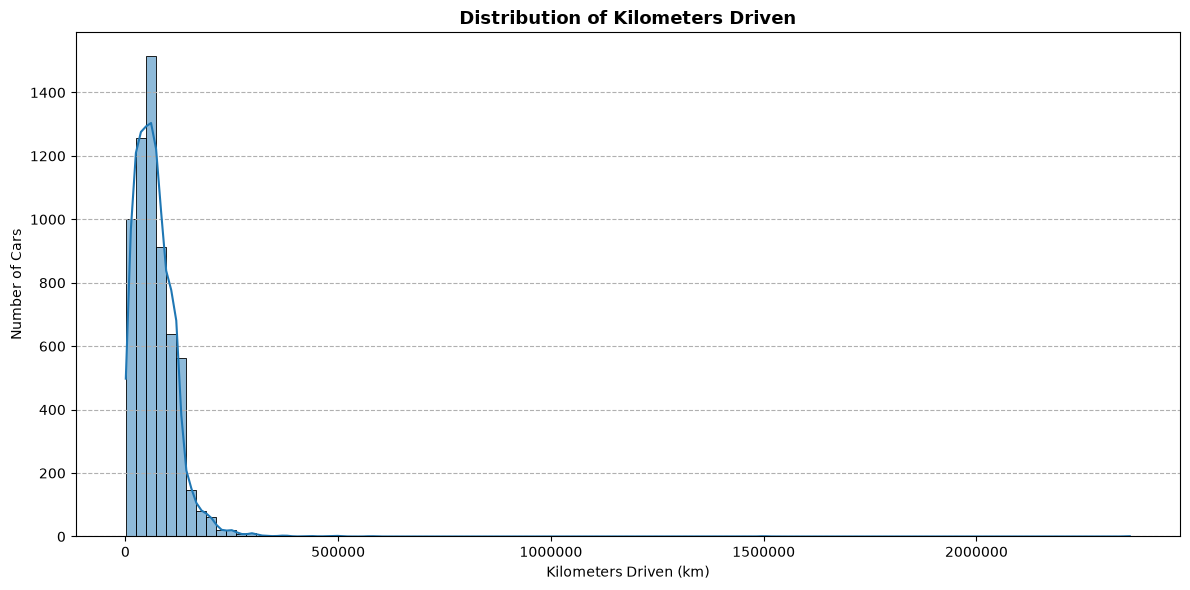

In [118]:

plt.figure(figsize=(12, 6))

# Plot the distribution of kilometers driven
sns.histplot(data=df_train, x='km_driven', kde=True, bins=100)

# Use plain formatting to avoid scientific notation on the X-axis (e.g., 2e5)
plt.ticklabel_format(style='plain', axis='x')

plt.title('Distribution of Kilometers Driven', fontsize=13, fontweight='bold')
plt.xlabel('Kilometers Driven (km)')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


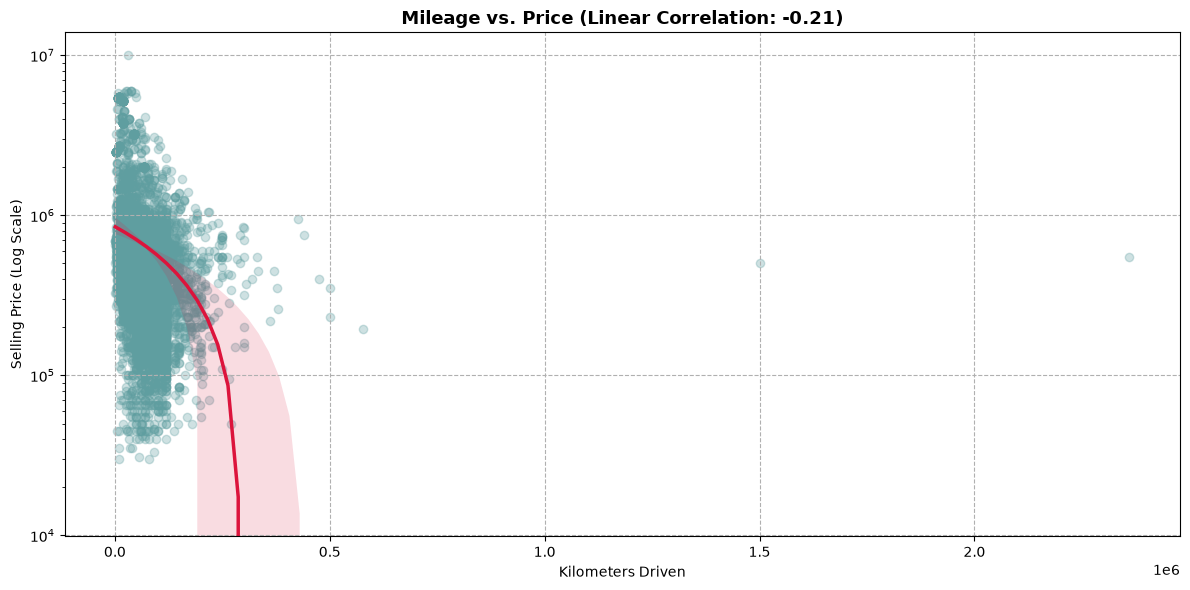

In [191]:
plt.figure(figsize=(12, 6))

# Calculate the correlation score to display in the title
km_price_corr = df_train['km_driven'].corr(df_train['selling_price'])

# Draw the scatter plot with an overlayed linear trendline
sns.regplot(
    data=df_train, 
    x='km_driven', 
    y='selling_price', 
    scatter_kws={'alpha': 0.3, 'color': "cadetblue"}, 
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)

# Apply a log scale on the Y-axis so pricing tiers remain visible across all ranges
plt.yscale('log')
# plt.ticklabel_format(style='plain', axis='both')

plt.title(f'Mileage vs. Price (Linear Correlation: {km_price_corr:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Log Scale)')
plt.grid(axis='both', linestyle='--')

plt.tight_layout()
plt.show()


### Fuel

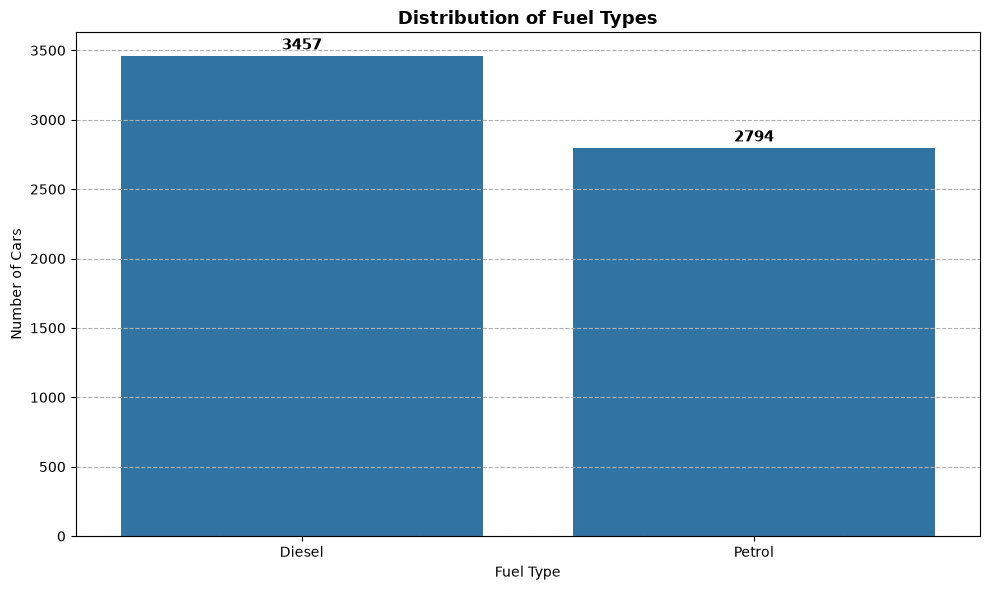

In [155]:

plt.figure(figsize=(10, 6))

# Plot the total count for each remaining fuel type
sns.countplot(data=df_train, x='fuel', order=df_train['fuel'].value_counts().index)

# Add values on top of the bars to make it clean and professional
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribution of Fuel Types', fontsize=13, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


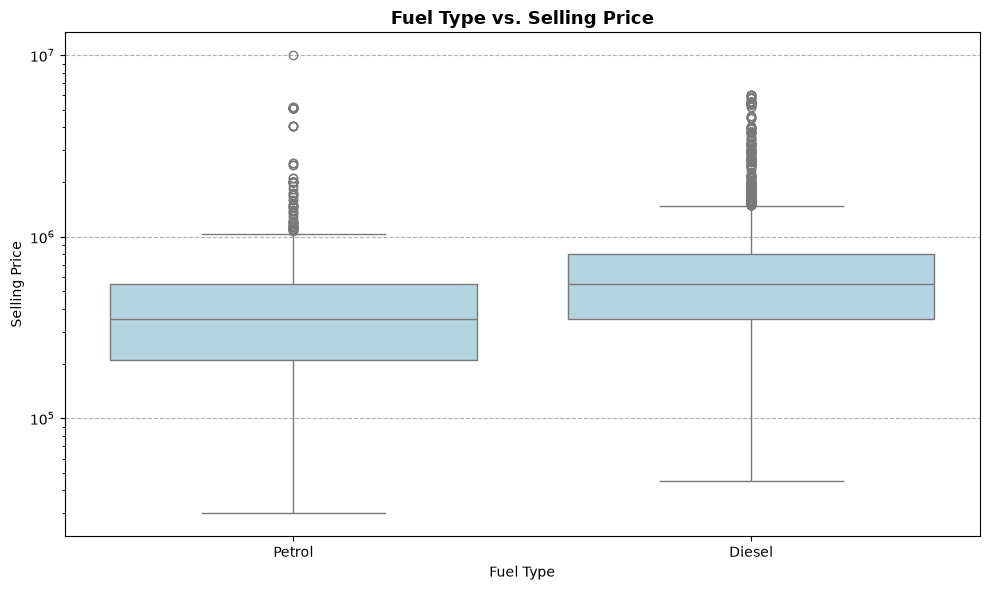

In [156]:
plt.figure(figsize=(10, 6))

# Plot the underlying box distributions
sns.boxplot(data=df_train, x='fuel', y='selling_price', color='lightblue')

# Overlay individual cars as small transparent dots to see real data density
# sns.stripplot(data=df_train, x='fuel', y='selling_price', order=df_train['fuel'].value_counts().index, 
#               size=4, alpha=0.3, jitter=0.2, hue='fuel', legend=False)

# Format the pricing axis cleanly
plt.yscale('log')

plt.title('Fuel Type vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


### Seller Type

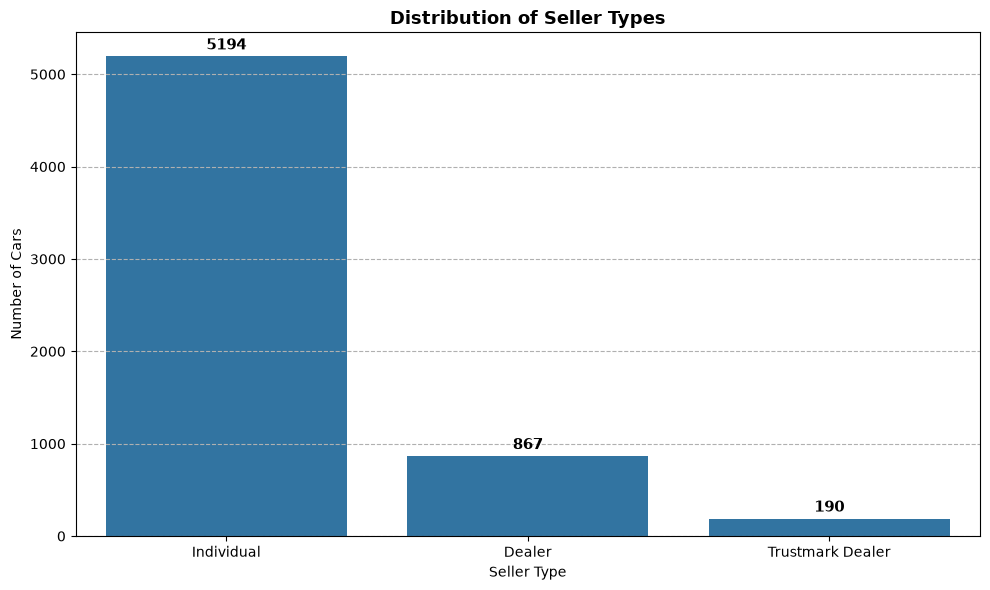

In [160]:


plt.figure(figsize=(10, 6))

# Plot the total count for each seller type
sns.countplot(data=df_train, x='seller_type')

# Add precise value labels on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribution of Seller Types', fontsize=13, fontweight='bold')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


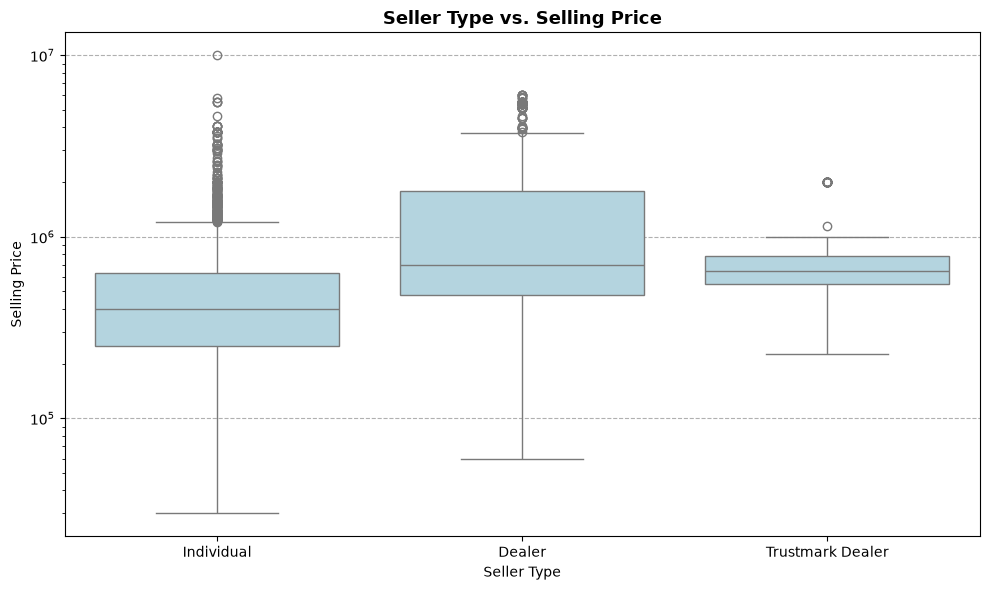

In [162]:
plt.figure(figsize=(10, 6))

# Plot the underlying box distributions
sns.boxplot(data=df_train, x='seller_type', y='selling_price', color='lightblue')

# Overlay individual cars as small transparent dots to see real data density
# sns.stripplot(data=df_train, x='seller_type', y='selling_price', order=df_train['seller_type'].value_counts().index, 
#               size=4, palette='Set2', alpha=0.3, jitter=0.2, hue='seller_type', legend=False)

# Format the pricing axis cleanly with a log scale
plt.yscale('log')

plt.title('Seller Type vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


### Transmission

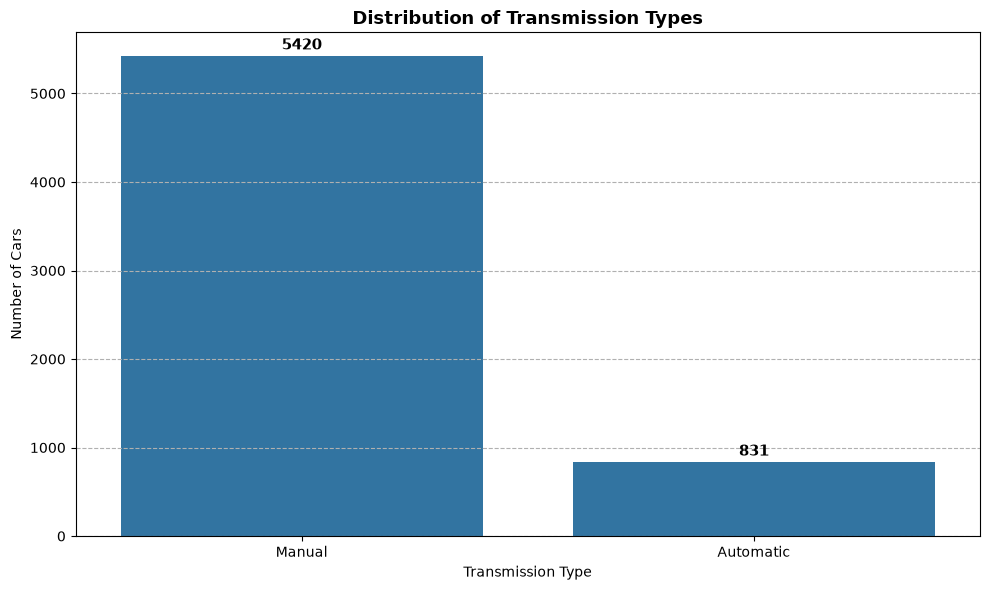

In [165]:

plt.figure(figsize=(10, 6))

# Plot the total count for each transmission type
sns.countplot(data=df_train, x='transmission', order=df_train['transmission'].value_counts().index)

# Add values on top of the bars to make it clean and professional
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribution of Transmission Types', fontsize=13, fontweight='bold')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


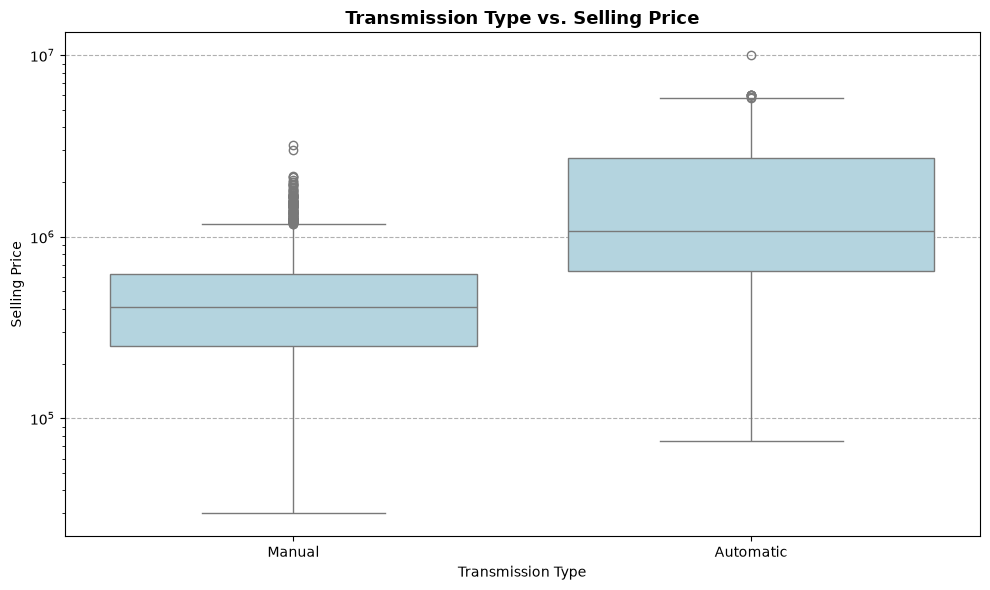

In [166]:
plt.figure(figsize=(10, 6))

# Plot the underlying box distributions
sns.boxplot(data=df_train, x='transmission', y='selling_price', color='lightblue')

# Overlay individual cars as small transparent dots to see real data density
# sns.stripplot(data=df_train, x='transmission', y='selling_price', order=df_train['transmission'].value_counts().index, 
#               size=4, palette='Set2', alpha=0.25, jitter=0.2, hue='transmission', legend=False)

# Format the pricing axis cleanly with a log scale
plt.yscale('log')

plt.title('Transmission Type vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


### Owner

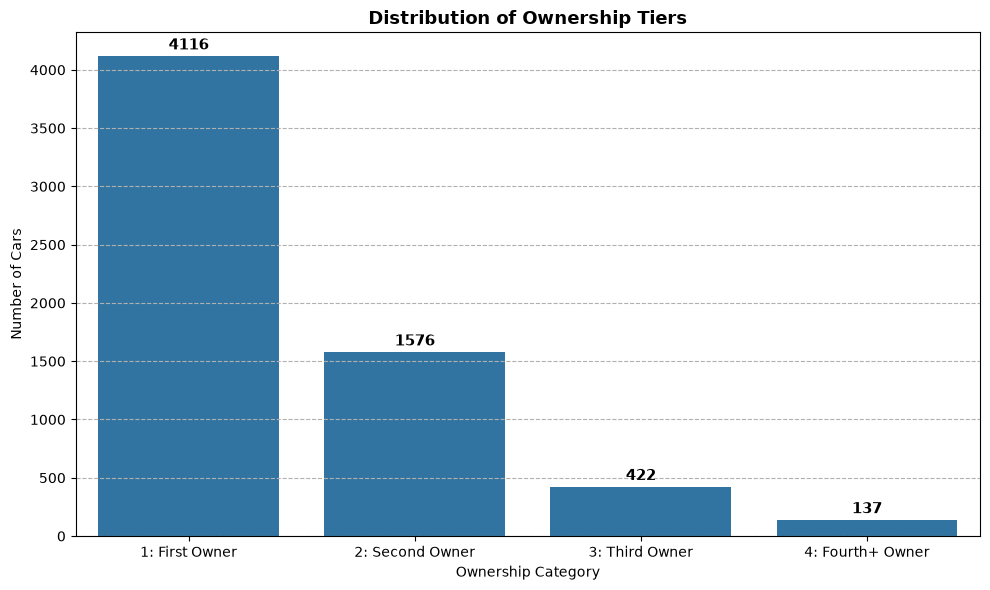

In [176]:

plt.figure(figsize=(10, 6))

# Plot the total count for each ownership category
sns.countplot(data=df_train, x='owner')
plt.xticks(
    ticks=[0, 1, 2, 3], 
    labels=['1: First Owner', '2: Second Owner', '3: Third Owner', '4: Fourth+ Owner']
)
# Add precise value labels on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribution of Ownership Tiers', fontsize=13, fontweight='bold')
plt.xlabel('Ownership Category')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


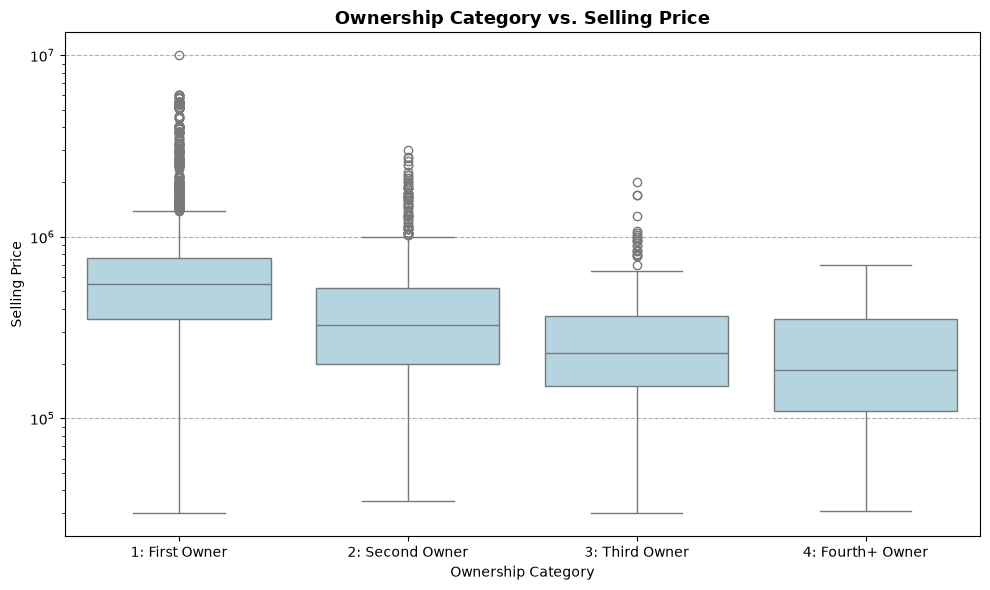

In [175]:
plt.figure(figsize=(10, 6))

# Plot the underlying box distributions
sns.boxplot(data=df_train, x='owner', y='selling_price', color='lightblue')

plt.xticks(
    ticks=[0, 1, 2, 3], 
    labels=['1: First Owner', '2: Second Owner', '3: Third Owner', '4: Fourth+ Owner']
)

# Overlay individual cars as small transparent dots to see real data density
# sns.stripplot(data=df_train, x='owner', y='selling_price', order=existing_order, 
#               size=4, palette='Set2', alpha=0.25, jitter=0.2, hue='owner', legend=False)

# Format the pricing axis cleanly with a log scale
plt.yscale('log')

plt.title('Ownership Category vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Ownership Category')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


### Mileage

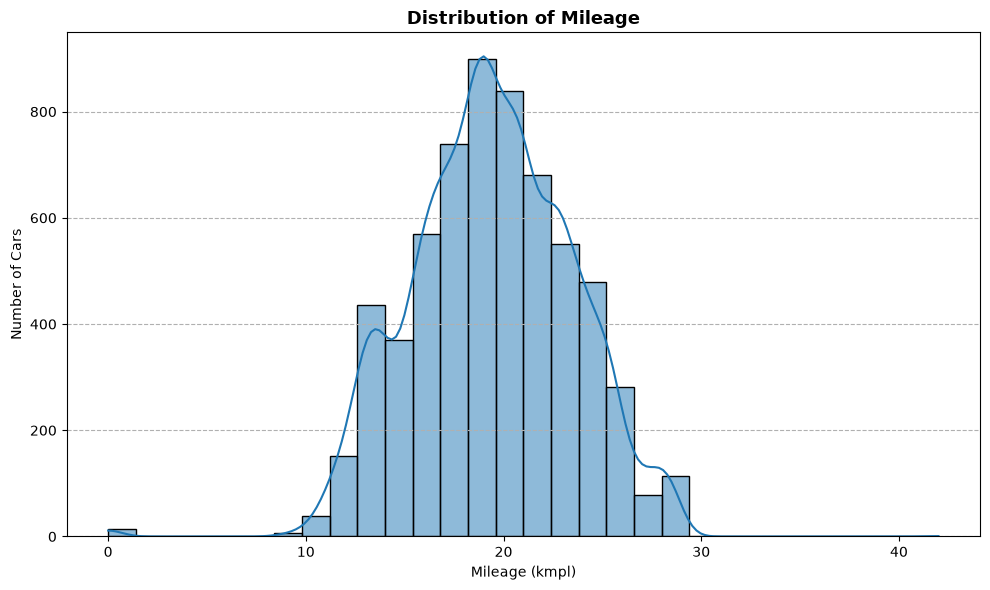

In [183]:

plt.figure(figsize=(10, 6))

# Plot the distribution of fuel economy (mileage)
sns.histplot(data=df_train, x='mileage', kde=True, bins=30)

plt.title('Distribution of Mileage', fontsize=13, fontweight='bold')
plt.xlabel('Mileage (kmpl)')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


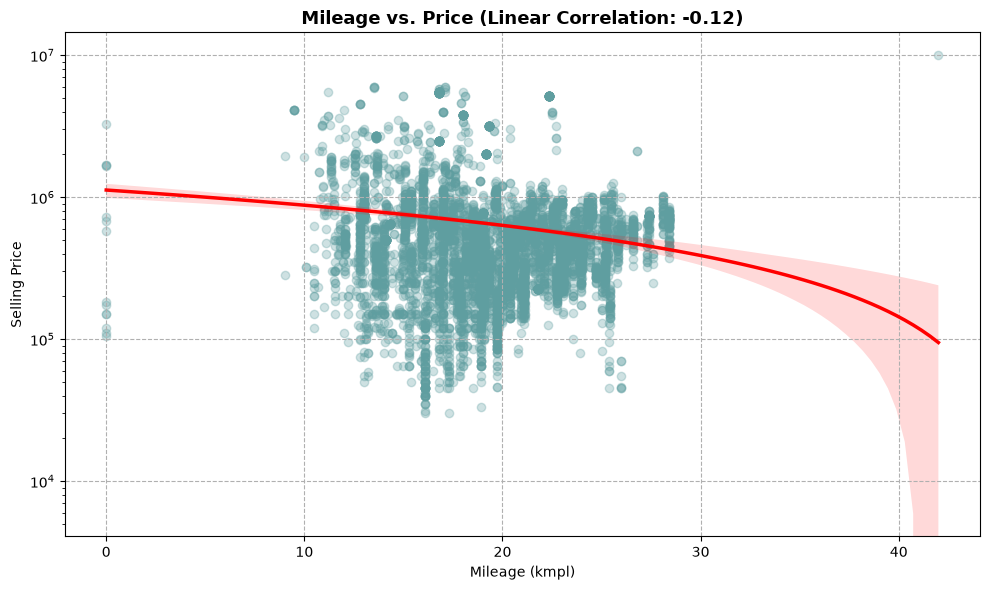

In [192]:
plt.figure(figsize=(10, 6))

# Calculate the correlation score to display in the title
mileage_price_corr = df_train['mileage'].corr(df_train['selling_price'])

# Draw the scatter plot with an overlayed linear trendline
sns.regplot(
    data=df_train, 
    x='mileage', 
    y='selling_price', 
    scatter_kws={'alpha': 0.3, 'color': 'cadetblue'}, 
    line_kws={'color': 'red', 'linewidth': 2.5}
)

# Apply a log scale on the Y-axis to handle the price variations cleanly
plt.yscale('log')

plt.title(f'Mileage vs. Price (Linear Correlation: {mileage_price_corr:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Mileage (kmpl)')
plt.ylabel('Selling Price')
plt.grid(axis='both', linestyle='--')

plt.tight_layout()
plt.show()


### Engine

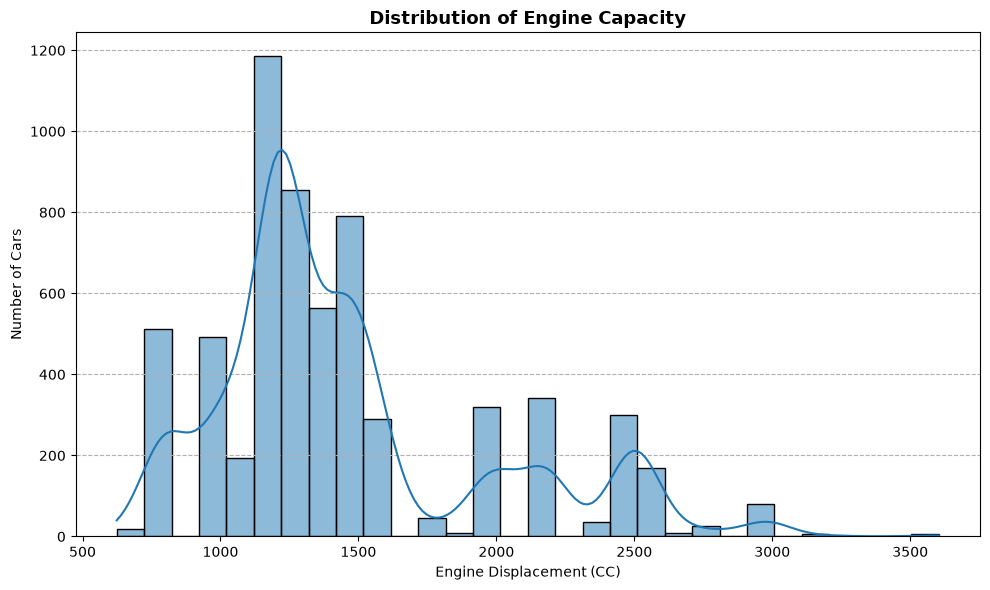

In [193]:
plt.figure(figsize=(10, 6))

# Plot the distribution of engine capacity
sns.histplot(data=df_train, x='engine', kde=True, bins=30)

plt.title('Distribution of Engine Capacity', fontsize=13, fontweight='bold')
plt.xlabel('Engine Displacement (CC)')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

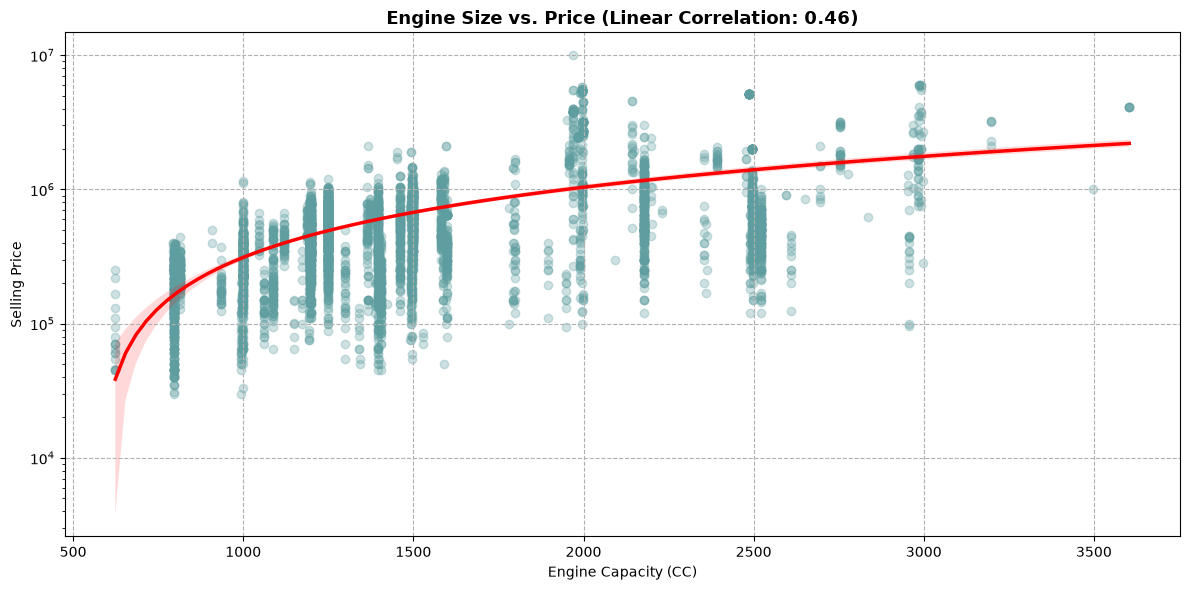

In [197]:
plt.figure(figsize=(12, 6))

# Calculate the correlation score to display in the title
engine_price_corr = df_train['engine'].corr(df_train['selling_price'])

# Draw the scatter plot with an overlayed linear trendline
sns.regplot(
    data=df_train, 
    x='engine', 
    y='selling_price', 
    scatter_kws={'alpha': 0.3, 'color': 'cadetblue'}, 
    line_kws={'color': 'red', 'linewidth': 2.5}
)

# Apply a log scale on the Y-axis to handle the price variations cleanly
plt.yscale('log')

plt.title(f'Engine Size vs. Price (Linear Correlation: {engine_price_corr:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Engine Capacity (CC)')
plt.ylabel('Selling Price')
plt.grid(axis='both', linestyle='--')

plt.tight_layout()
plt.show()


### Max Power

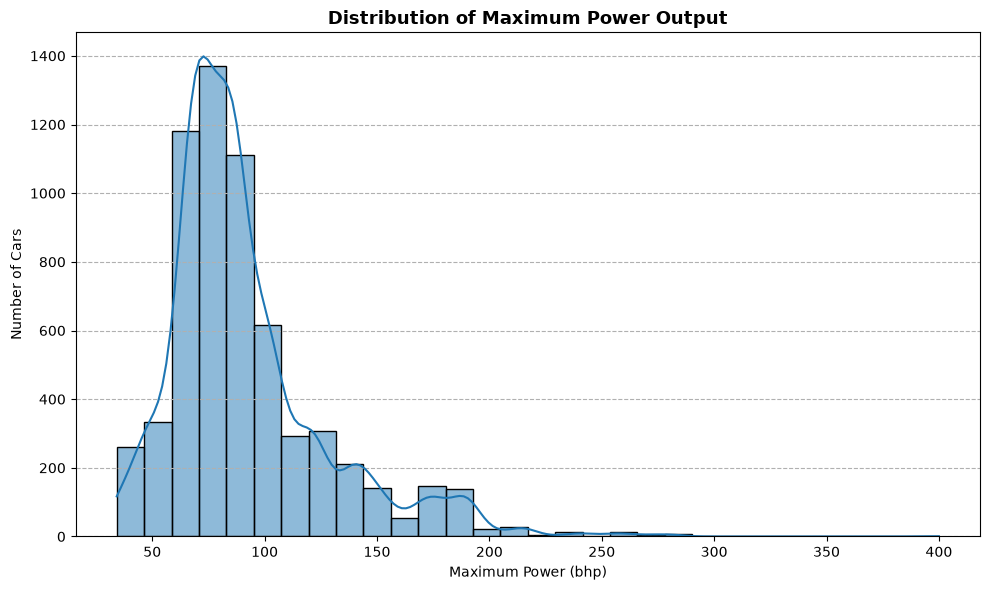

In [199]:

plt.figure(figsize=(10, 6))

# Plot the distribution of max power output
sns.histplot(data=df_train, x='max_power', kde=True, bins=30)

plt.title('Distribution of Maximum Power Output', fontsize=13, fontweight='bold')
plt.xlabel('Maximum Power (bhp)')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


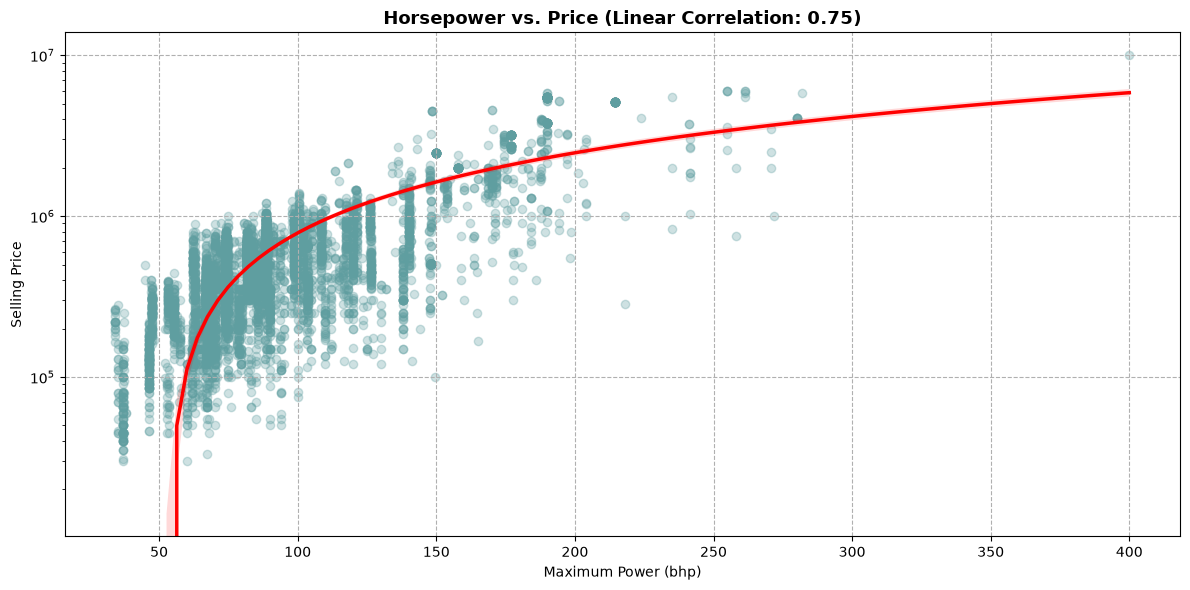

In [200]:
plt.figure(figsize=(12, 6))

# Calculate the correlation score to display in the title
power_price_corr = df_train['max_power'].corr(df_train['selling_price'])

# Draw the scatter plot with an overlayed linear trendline
sns.regplot(
    data=df_train, 
    x='max_power', 
    y='selling_price', 
    scatter_kws={'alpha': 0.3, 'color': 'cadetblue'}, 
    line_kws={'color': 'red', 'linewidth': 2.5}
)

# Apply a log scale on the Y-axis to keep trend lines steady across price tiers
plt.yscale('log')

plt.title(f'Horsepower vs. Price (Linear Correlation: {power_price_corr:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Maximum Power (bhp)')
plt.ylabel('Selling Price')
plt.grid(axis='both', linestyle='--')

plt.tight_layout()
plt.show()


### Seats

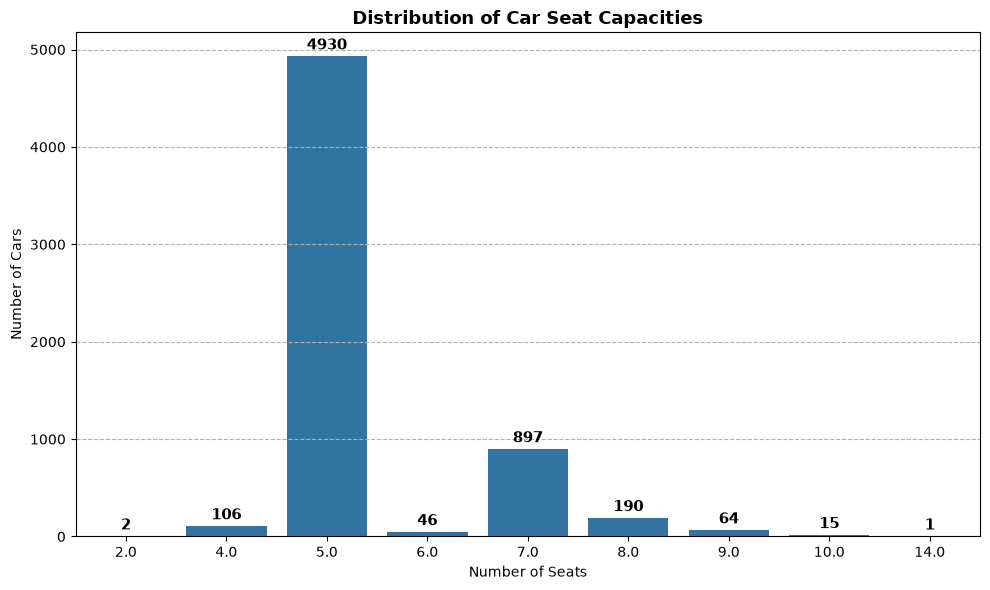

In [201]:
plt.figure(figsize=(10, 6))

# Plot the total count for each seat category, sorted by seat count order
sns.countplot(data=df_train, x='seats')

# Add values on top of the bars to make it clean and professional
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0: # Only annotate bars that have data
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', 
                    xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribution of Car Seat Capacities', fontsize=13, fontweight='bold')
plt.xlabel('Number of Seats')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

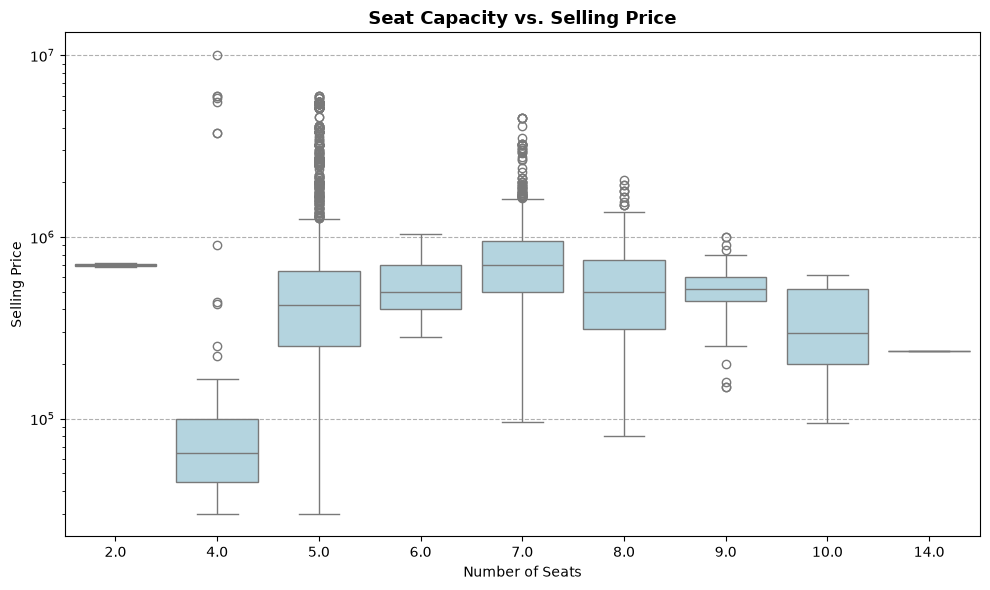

In [204]:
plt.figure(figsize=(10, 6))

# Plot the underlying box distributions across seating tiers
sns.boxplot(data=df_train, x='seats', y='selling_price', color='lightblue')

# Overlay individual cars as small transparent dots to see real data density
# sns.stripplot(data=df_train, x='seats', y='selling_price', size=4, palette='Set2', alpha=0.25, jitter=0.2, hue='seats', legend=False)

# Format the pricing axis cleanly with a log scale
plt.yscale('log')

plt.title('Seat Capacity vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Number of Seats')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

### All

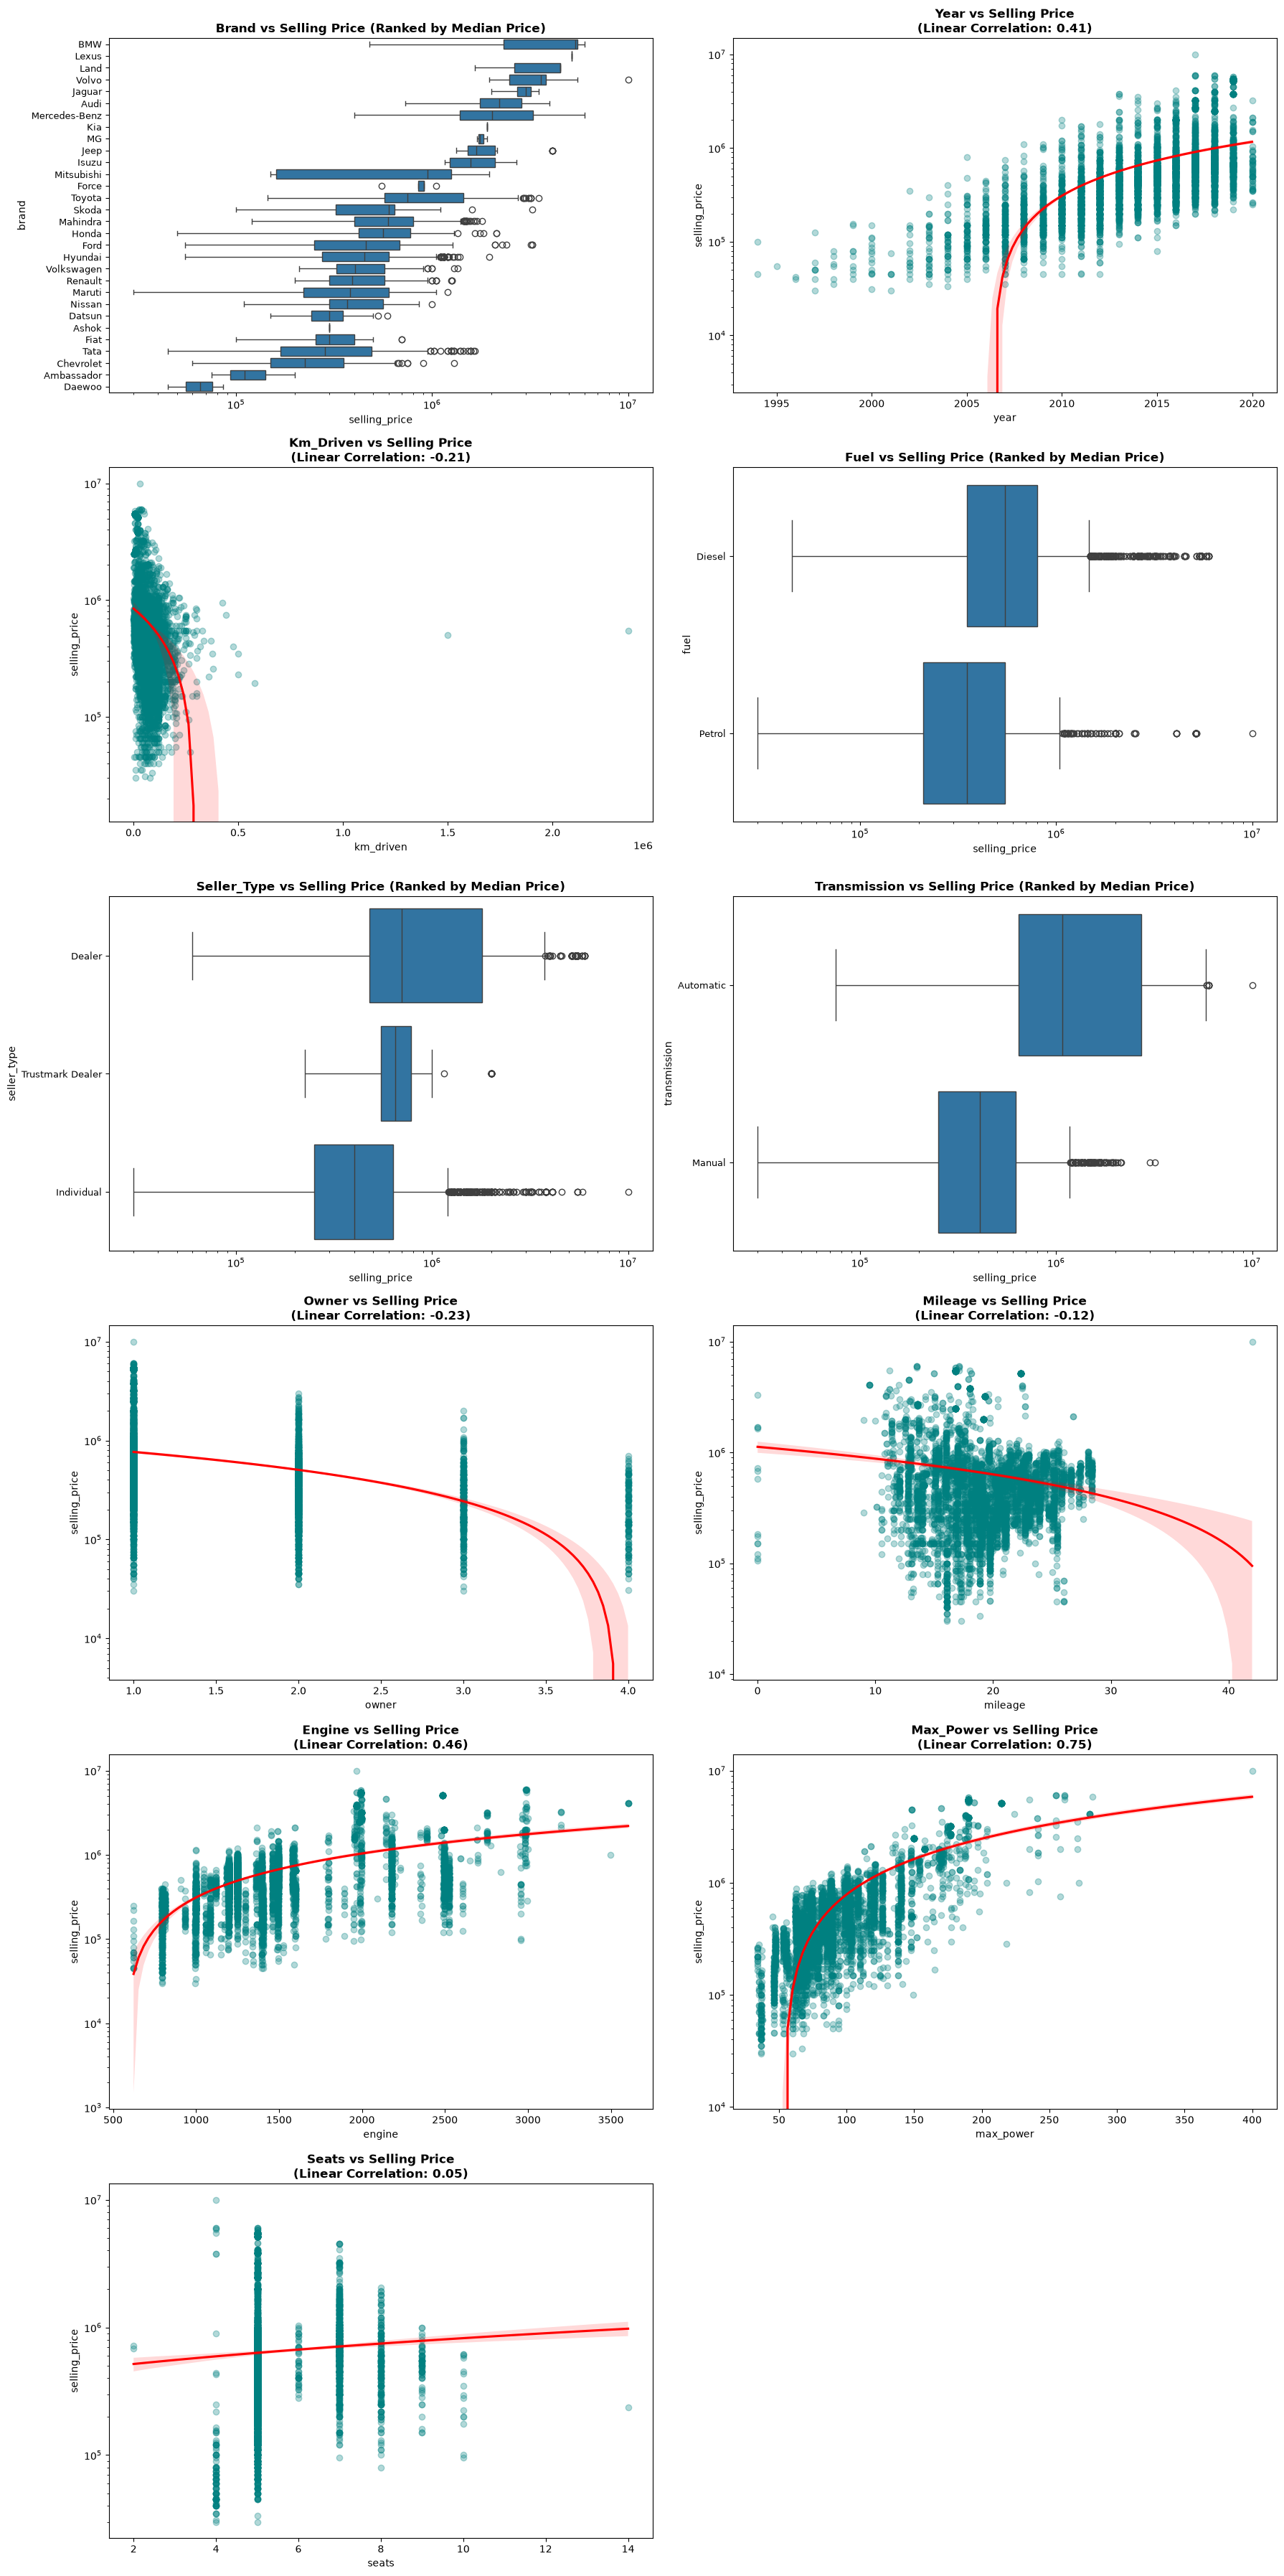

In [64]:

# 1. Separate your features (excluding the target itself)
features_to_plot = [col for col in df_train.columns if col not in ['selling_price', 'selling_price_log']]

# 2. Set up a dynamic grid layout
num_plots = len(features_to_plot)
cols = 2
rows = (num_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 6))
axes = axes.flatten()

# 3. Loop through every feature and compare it to selling_price
for i, col in enumerate(features_to_plot):
    
    # Check if the column is Numeric (Numbers)
    if df_train[col].dtype in ['int64', 'float64']:
        # Calculate standard Pearson correlation
        corr_val = df_train[col].corr(df_train['selling_price'])
        
        # Draw a scatter plot with a linear trendline
        sns.regplot(data=df_train, x=col, y='selling_price', ax=axes[i],
                    scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
        
        axes[i].set_title(f'{col.title()} vs Selling Price\n(Linear Correlation: {corr_val:.2f})', fontweight='bold')
        axes[i].set_yscale('log') # Keeps pricing variations clean to read
        
    # Check if the column is Categorical (Text strings)
    else:
        # Calculate the median price per category to rank them visually
        cat_order = df_train.groupby(col)['selling_price'].median().sort_values(ascending=False).index
        
        # Draw a clean horizontal boxplot
        sns.boxplot(data=df_train, x='selling_price', y=col, ax=axes[i], order=cat_order)
        
        axes[i].set_title(f'{col.title()} vs Selling Price (Ranked by Median Price)', fontweight='bold')
        axes[i].set_xscale('log')
        axes[i].tick_params(axis='y', labelsize=9)

# 4. Remove any trailing blank subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Summary here
Task 2. Report - In the end of the notebook, please write a 2-3 paragraphs summary deeply discussing and analysing the results. 
Possible points of discussion:
- Which features are important? Which are not? Why?
- Which algorithm performs well? Which does not? Why?

In [ ]:
### Write webpage for public use. Deploy.